In [41]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import glob
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input

# reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ["0", "1", "2", "3", "4"]

In [42]:
def load_messidor(path):
    df = pd.read_csv(os.path.join(path, "messidor_data.csv"))

    img_paths = glob.glob(os.path.join(path, "**/*.*"), recursive=True)
    img_map = {os.path.basename(p): p for p in img_paths}

    df["full_path"] = df["id_code"].map(img_map)
    df["diagnosis"] = df["diagnosis"].astype(str)

    df = df[df["full_path"].notna()]
    df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)

    return df

In [43]:
def load_ddr(path, n_total=5000):
    img_dir = os.path.join(path, "DR_grading", "DR_grading")

    df = pd.read_csv(os.path.join(path, "DR_grading.csv"))

    df["full_path"] = df["id_code"].apply(lambda x: os.path.join(img_dir, x))
    df["diagnosis"] = df["diagnosis"].astype(str)

    df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)

    # balanced sampling
    classes = df["diagnosis"].unique()
    n_per_class = n_total // len(classes)

    df = df.groupby("diagnosis", group_keys=False).apply(
        lambda x: x.sample(min(len(x), n_per_class), random_state=42)
    ).reset_index(drop=True)

    return df

In [44]:
def split_data(df):
    df = df.copy()
    df["patient_id"] = df["id_code"].apply(lambda x: x.split("_")[0])

    splitter = GroupShuffleSplit(test_size=0.2, random_state=42)

    train_idx, test_idx = next(splitter.split(df, groups=df["patient_id"]))
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    train_idx, val_idx = next(splitter.split(train_df, groups=train_df["patient_id"]))
    val_df = train_df.iloc[val_idx]
    train_df = train_df.iloc[train_idx]

    return train_df, val_df, test_df

In [46]:
def make_generators(train_df, val_df, test_df):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        zoom_range=0.1,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col="full_path", y_col="diagnosis",
        target_size=IMG_SIZE,
        class_mode="categorical",
        classes=CLASSES,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_gen = val_datagen.flow_from_dataframe(
        val_df, x_col="full_path", y_col="diagnosis",
        target_size=IMG_SIZE,
        class_mode="categorical",
        classes=CLASSES,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_gen = val_datagen.flow_from_dataframe(
        test_df, x_col="full_path", y_col="diagnosis",
        target_size=IMG_SIZE,
        class_mode="categorical",
        classes=CLASSES,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [47]:
def get_class_weights(train_df):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array(CLASSES),
        y=train_df["diagnosis"]
    )
    return dict(zip(range(len(CLASSES)), weights))

In [48]:
def build_efficientnet():
    base = EfficientNetB0(weights="imagenet", include_top=False)
    base.trainable = False

    inputs = tf.keras.Input((224,224,3))
    x = base(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(5, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [49]:
def build_resnet():
    base = ResNet50(weights="imagenet", include_top=False)
    base.trainable = False

    inputs = tf.keras.Input((224,224,3))
    x = base(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(5, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [58]:
def build_transfer(pretrained_model):
    pretrained_model.trainable = False

    inputs = tf.keras.Input((224,224,3))
    x = pretrained_model(inputs, training=False)

    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(5, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [59]:
def get_models():
    return {
        "EfficientNet": build_efficientnet(),
        "ResNet50": build_resnet(),
        "Transfer": build_transfer(
            tf.keras.models.load_model("pretrained_dr_model.h5")
        )
    }

In [60]:
def train_and_evaluate(model, train_gen, val_gen, test_gen, class_weights):

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        class_weight=class_weights,
        verbose=1
    )

    test_gen.reset()
    preds = model.predict(test_gen)
    pred_labels = np.argmax(preds, axis=1)
    y_true = test_gen.labels

    acc = accuracy_score(y_true, pred_labels)
    f1 = f1_score(y_true, pred_labels, average="weighted")
    cm = confusion_matrix(y_true, pred_labels)

    return acc, f1, cm

In [61]:
all_results = {"messidor": {}, "ddr": {}}

path = kagglehub.dataset_download("mariaherrerot/messidor2preprocess")
df = load_messidor(path)

train_df, val_df, test_df = split_data(df)
train_gen, val_gen, test_gen = make_generators(train_df, val_df, test_df)

class_weights = get_class_weights(train_df)

models_dict = get_models()

for name, model in models_dict.items():
    acc, f1, cm = train_and_evaluate(model, train_gen, val_gen, test_gen, class_weights)

    all_results["messidor"][name] = {
        "acc": acc,
        "f1": f1,
        "cm": cm
    }

del df, path

Found 1245 validated image filenames belonging to 5 classes.
Found 272 validated image filenames belonging to 5 classes.
Found 227 validated image filenames belonging to 5 classes.


Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 573ms/step - accuracy: 0.2747 - loss: 1.6243 - val_accuracy: 0.5221 - val_loss: 1.3561
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 543ms/step - accuracy: 0.3462 - loss: 1.4538 - val_accuracy: 0.5551 - val_loss: 1.2384
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 557ms/step - accuracy: 0.3807 - loss: 1.3910 - val_accuracy: 0.5221 - val_loss: 1.2116
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 580ms/step - accuracy: 0.4112 - loss: 1.2873 - val_accuracy: 0.4853 - val_loss: 1.2579
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 736ms/step - accuracy: 0.4273 - loss: 1.2833 - val_accuracy: 0.5147 - val_loss: 1.1933
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 657ms/step
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.2474 - loss: 1.8599 - val_accuracy: 0.3493 - val_loss: 1.4614
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.3068 - loss: 1.6644 - val_accuracy: 0.4118 - val_loss: 1.3974
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.3325 -

In [62]:
path = kagglehub.dataset_download("mariaherrerot/ddrdataset")
df = load_ddr(path, n_total=5000)

train_df, val_df, test_df = split_data(df)
train_gen, val_gen, test_gen = make_generators(train_df, val_df, test_df)

class_weights = get_class_weights(train_df)

models_dict = get_models()   # RESET MODELS

for name, model in models_dict.items():
    acc, f1, cm = train_and_evaluate(model, train_gen, val_gen, test_gen, class_weights)

    all_results["ddr"][name] = {
        "acc": acc,
        "f1": f1,
        "cm": cm
    }

Found 2418 validated image filenames belonging to 5 classes.
Found 605 validated image filenames belonging to 5 classes.
Found 756 validated image filenames belonging to 5 classes.


/var/folders/14/drwtsk3n2wvdsmw2rj7tqh040000gn/T/ipykernel_4121/641140632.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("diagnosis", group_keys=False).apply(


Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 68s 836ms/step - accuracy: 0.3970 - loss: 1.4206 - val_accuracy: 0.4744 - val_loss: 1.2344
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 72s 951ms/step - accuracy: 0.4748 - loss: 1.2510 - val_accuracy: 0.4826 - val_loss: 1.1784
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 68s 893ms/step - accuracy: 0.4979 - loss: 1.1875 - val_accuracy: 0.5107 - val_loss: 1.1212
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 65s 843ms/step - accuracy: 0.5219 - loss: 1.1406 - val_accuracy: 0.4645 - val_loss: 1.2126
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 68s 878ms/step - accuracy: 0.5256 - loss: 1.1147 - val_accuracy: 0.5157 - val_loss: 1.0973
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 656ms/step
Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.3644 - loss: 1.5392 - val_accuracy: 0.4909 - val_loss: 1.1821
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.4516 - loss: 1.2953 - val_accuracy: 0.5041 - val_loss: 1.1213
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.49

In [63]:
def to_df(results_dict, dataset_name):
    df = pd.DataFrame(results_dict).T
    df["dataset"] = dataset_name
    return df.reset_index().rename(columns={"index": "model"})

messidor_df = to_df(all_results["messidor"], "Messidor")
ddr_df = to_df(all_results["ddr"], "DDR")

final_df = pd.concat([messidor_df, ddr_df])
print(final_df)

          model       acc        f1  \
0  EfficientNet  0.594714  0.631538   
1      ResNet50  0.343612  0.422693   
2      Transfer   0.76652  0.690808   
0  EfficientNet  0.533069  0.517895   
1      ResNet50   0.53836  0.516338   
2      Transfer   0.19709  0.142438   

                                                  cm   dataset  
0  [[131, 6, 17, 23, 0], [14, 1, 6, 6, 0], [12, 0...  Messidor  
1  [[62, 9, 99, 0, 7], [6, 3, 17, 0, 1], [6, 0, 9...  Messidor  
2  [[172, 0, 5, 0], [26, 0, 1, 0], [16, 0, 2, 0],...  Messidor  
0  [[128, 62, 7, 2, 4], [31, 82, 7, 4, 5], [31, 7...       DDR  
1  [[186, 10, 4, 1, 2], [75, 40, 5, 6, 3], [83, 3...       DDR  
2  [[33, 0, 0, 3, 167], [3, 0, 2, 5, 119], [7, 0,...       DDR  


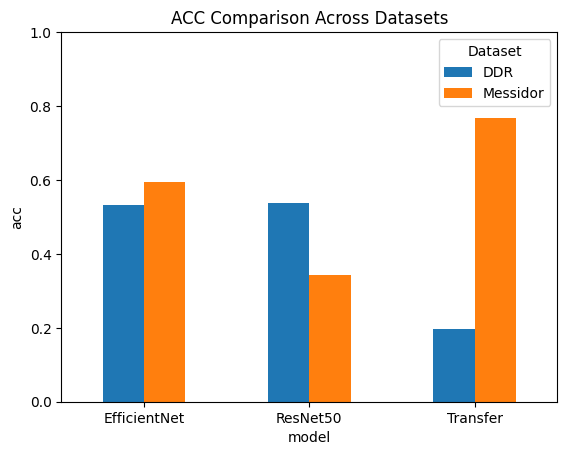

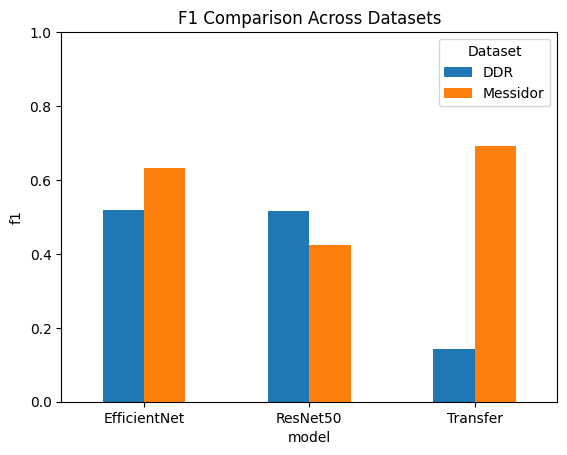

In [64]:
import matplotlib.pyplot as plt

for metric in ["acc", "f1"]:
    pivot = final_df.pivot(index="model", columns="dataset", values=metric)

    pivot.plot(kind="bar")
    plt.title(f"{metric.upper()} Comparison Across Datasets")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.legend(title="Dataset")
    plt.show()

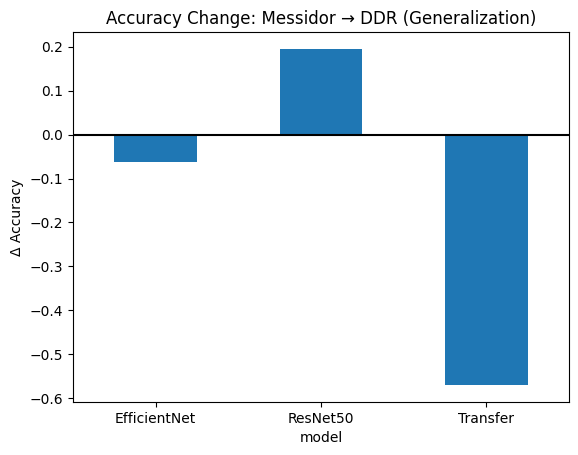

In [65]:
pivot = final_df.pivot(index="model", columns="dataset", values="acc")

pivot["drop"] = pivot["DDR"] - pivot["Messidor"]

pivot["drop"].plot(kind="bar")
plt.title("Accuracy Change: Messidor → DDR (Generalization)")
plt.ylabel("Δ Accuracy")
plt.axhline(0, color="black")
plt.xticks(rotation=0)
plt.show()

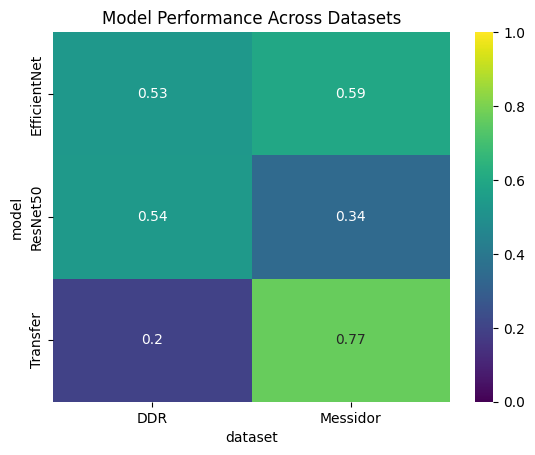

In [68]:
import seaborn as sns

final_df["acc"] = pd.to_numeric(final_df["acc"], errors="coerce")

pivot = final_df.pivot_table(
    index="model",
    columns="dataset",
    values="acc",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Model Performance Across Datasets")
plt.show()